**PORTFOLIO 4**

In [ ]:
# Basic data manipulation and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importing regression and clustering libraries
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import RFE
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsClassifier # Import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report

# Metrics for classification, etc.
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Set plot style for better visualization
sns.set(style="whitegrid")


In [ ]:
# Load the dataset
df = pd.read_csv('/content/wine-clustering.csv')  # Adjust the path if necessary

# Display the first few rows to understand the dataset
df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


### Data Source:
This dataset is sourced from **Kaggle**. It is publicly available and widely used for regression, classification, and clustering tasks in machine learning research and applications.

- **Dataset Name**: Wine Dataset for Clustering
- **Source**: Kaggle
- **Link to Dataset**: (https://www.kaggle.com/datasets/harrywang/wine-dataset-for-clustering)

This dataset is well-suited for analyzing relationships between wine composition and quality, particularly through classification, regression, and clustering techniques.

### Brief Description of the Dataset
The dataset contains chemical properties of various wine samples. Each wine sample is characterized by 13 continuous numerical features, detailing different aspects of its composition. The dataset's goal is to explore how these chemical properties relate to certain quality indicators, such as alcohol content, and to potentially group wines into distinct categories based on these characteristics.


# Problem Definition and Purpose of Analysis

In this analysis, we aim to explore and understand the relationships between the chemical properties of wine and how they influence key quality factors such as alcohol content. We will also investigate the natural groupings within the wines based on their chemical properties using clustering techniques. The analysis will be driven by the following well-defined questions:

## 1. Can we accurately predict the alcohol content of wine using its chemical properties?

**Purpose:** To build predictive models using both linear and polynomial regression, as well as K-Nearest Neighbors (KNN) and Naive Bayes classifiers, to estimate the alcohol content in wine based on measurable chemical properties such as Ash, Proline, and Flavanoids. Predicting alcohol content is important because it is a key factor in wine quality assessment, and having accurate prediction models can help winemakers improve production processes.

## 2. Which chemical properties are the most important for predicting alcohol content?

**Purpose:** To identify the most influential chemical properties using Recursive Feature Elimination (RFE). By understanding which features have the greatest impact on predicting alcohol content, winemakers can focus on controlling and monitoring those specific properties during the wine-making process, leading to better quality control.

## 3. Can we identify natural clusters of wines based on their chemical composition, and how do these clusters differ in terms of alcohol content or other characteristics?

**Purpose:** To use K-Means clustering to group wines based on their chemical properties and investigate how these groups vary in terms of alcohol content or other important characteristics. This clustering could help identify different types of wines (e.g., high-alcohol vs. low-alcohol wines) or even reveal patterns that suggest new wine blends.

## 4. Does applying polynomial regression improve the accuracy of predicting alcohol content compared to linear regression?

**Purpose:** To evaluate whether polynomial regression offers better predictive performance over a simple linear regression model. Polynomial regression can capture more complex relationships in the data, and this step will assess if it enhances prediction accuracy for alcohol content.

## 5. How do KNN and Naive Bayes classifiers perform in predicting wine quality based on chemical properties?

**Purpose:** To explore the effectiveness of K-Nearest Neighbors (KNN) and Naive Bayes classifiers in predicting wine quality based on selected features. By comparing these models, we can determine which algorithm provides better predictive power and insights into wine classification based on its chemical composition.

---

This analysis will utilize various techniques learned throughout the course, including:
- **Unsupervised Learning:** K-Means Clustering
- **Supervised Learning:** Linear Regression, Polynomial Regression, K-Nearest Neighbors (KNN), and Naive Bayes Classifier
- **Feature Selection:** Recursive Feature Elimination (RFE)

By addressing these questions, we aim to provide valuable insights that can enhance wine quality and production processes.


In [ ]:
# Checking for missing values and data types
df.info()

# Summary statistics of the dataset
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


**Exploratory Data Analysis**

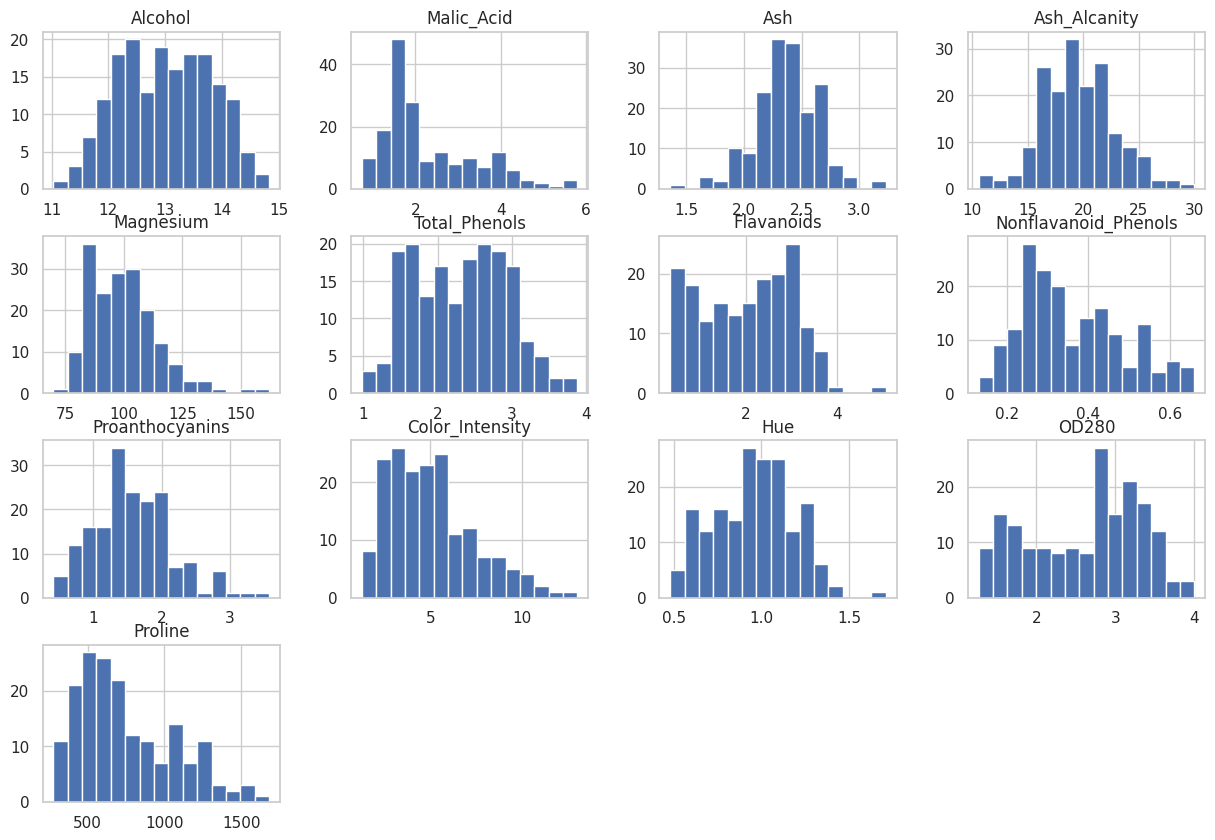

In [ ]:
#Univariate Analysis (distribution of each feature)
# Visualizing distribution of each feature
df.hist(bins=15, figsize=(15, 10))
plt.show()


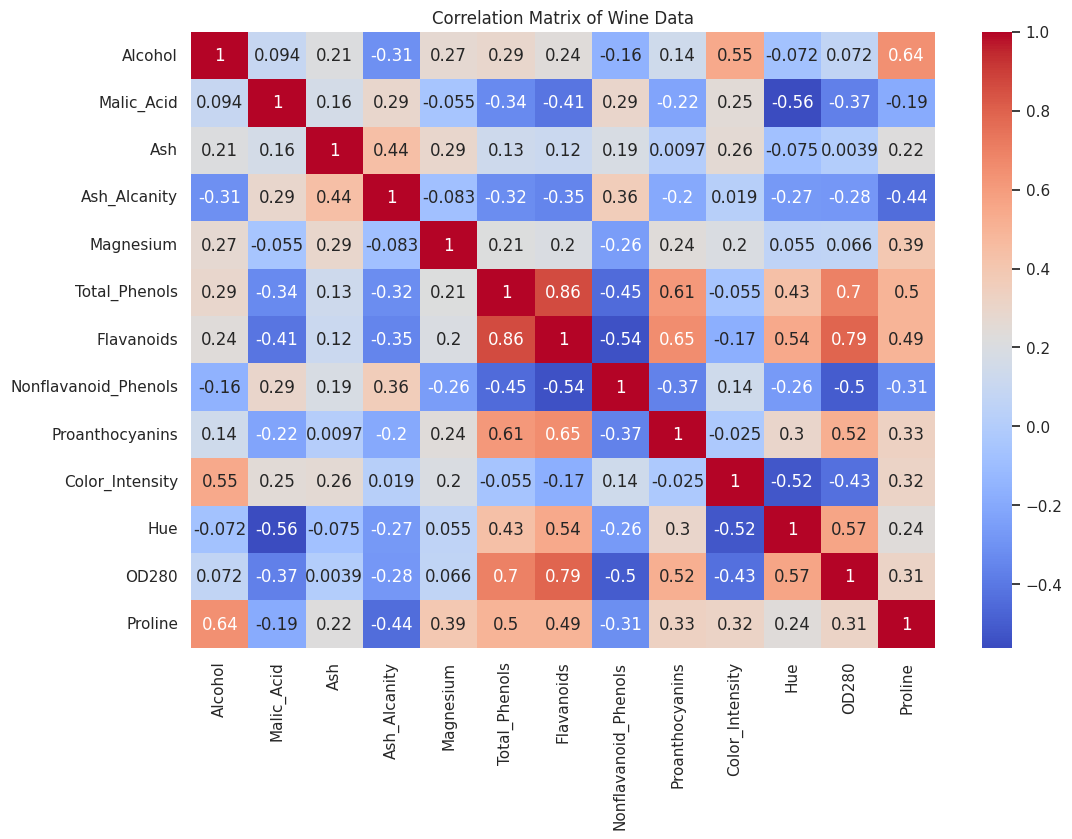

In [ ]:
# Correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Wine Data')
plt.show()

**Feature Selection using RFE**

In [ ]:
X = df.drop('Alcohol', axis=1)  # Features (excluding Alcohol)
y = df['Alcohol']  # Target variable


In [ ]:
# Applying RFE with Linear Regression as estimator
lr = LinearRegression()
rfe = RFE(estimator=lr, n_features_to_select=5)  # Select top 5 features
rfe.fit(X, y)

# Display selected features
selected_features = X.columns[rfe.support_]
print("Selected Features:", selected_features)

# Reduce X to only selected features
X_rfe = X[selected_features]

Selected Features: Index(['Total_Phenols', 'Nonflavanoid_Phenols', 'Color_Intensity', 'Hue',
       'OD280'],
      dtype='object')



After applying Recursive Feature Elimination (RFE), the most important features for predicting the alcohol content in wine were identified as:

- Total_Phenols
- Nonflavanoid_Phenols
- Color_Intensity
- Hue
- OD280

These features appear to have the most influence on the alcohol content of wine. Therefore, future analysis will be based on these selected features.


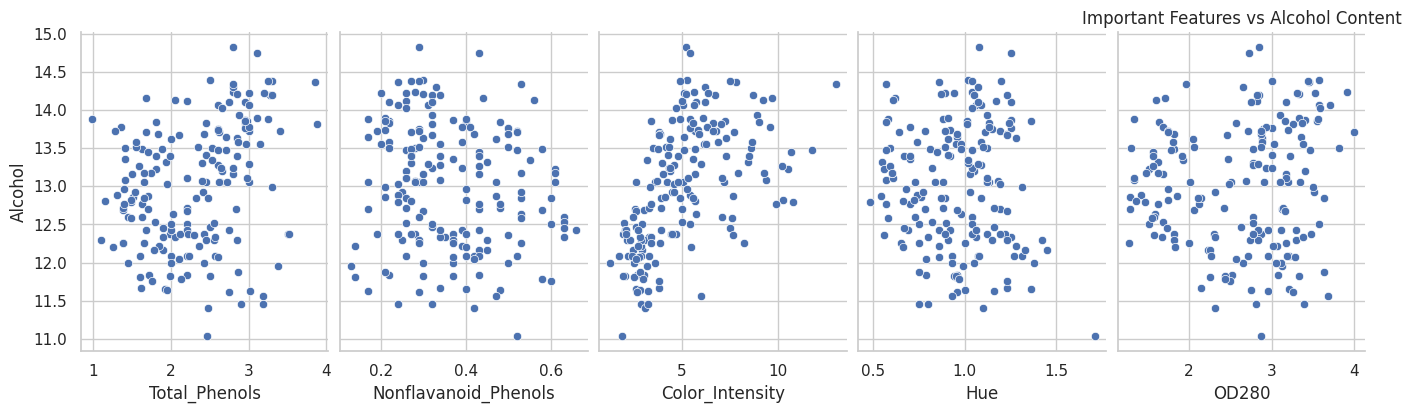

In [ ]:
#Visualisation
# Scatter plot to show relationship between selected features and alcohol
sns.pairplot(df, x_vars=selected_features, y_vars='Alcohol', kind='scatter', height=4, aspect=0.7)
plt.title('Important Features vs Alcohol Content')
plt.show()


**Linear Regression and Polynomial Regression**

In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_rfe, y, test_size=0.2, random_state=42)


In [ ]:
# Linear regression model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict on test set
y_pred_lr = lr.predict(X_test)

# Evaluation of the linear regression model
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
print(f"Linear Regression MSE: {mse_lr}, R-squared: {r2_lr}")


Linear Regression MSE: 0.277744272320389, R-squared: 0.5347946116937483


In [ ]:
# Polynomial regression with degree 2
poly = PolynomialFeatures(degree=2)
poly_lr = make_pipeline(poly, LinearRegression())

# Fit the model
poly_lr.fit(X_train, y_train)

# Predict on test set
y_pred_poly = poly_lr.predict(X_test)

# Evaluation of polynomial regression model
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)
print(f"Polynomial Regression MSE: {mse_poly}, R-squared: {r2_poly}")


Polynomial Regression MSE: 0.25658904993270637, R-squared: 0.5702283701052068


### **Interpretation and Insights**:

1. **Mean Squared Error (MSE)**:
   - MSE measures the average of the squared differences between the actual and predicted values. A **lower MSE** indicates better performance.
   - The **Polynomial Regression** model has a slightly lower MSE (0.2566) compared to the Linear Regression model (0.2777). This suggests that the polynomial regression model is doing a **better job at minimizing prediction errors** and making more accurate predictions of the alcohol content in wine.

2. **R-squared (R²)**:
   - R-squared indicates the proportion of the variance in the dependent variable (alcohol content) that is predictable from the independent variables (chemical properties). A **higher R-squared** indicates a better fit.
   - The **Polynomial Regression** model has a higher R-squared value (0.5702) compared to the Linear Regression model (0.5348). This means that the polynomial model explains **more variance** in the data, capturing more of the complexity in the relationship between the chemical properties and alcohol content.

### **Conclusion**:
- The Polynomial Regression model performs better than the Linear Regression model, both in terms of **lower error (MSE)** and **higher explained variance (R-squared)**.
- This improvement suggests that the relationship between the wine's chemical properties and its alcohol content is **non-linear**, and the polynomial regression model is able to capture these more complex interactions, resulting in better predictions.

Thus, using polynomial regression improves the accuracy and performance of the predictive model in this case.


**Clustering with K-Means**

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_rfe)


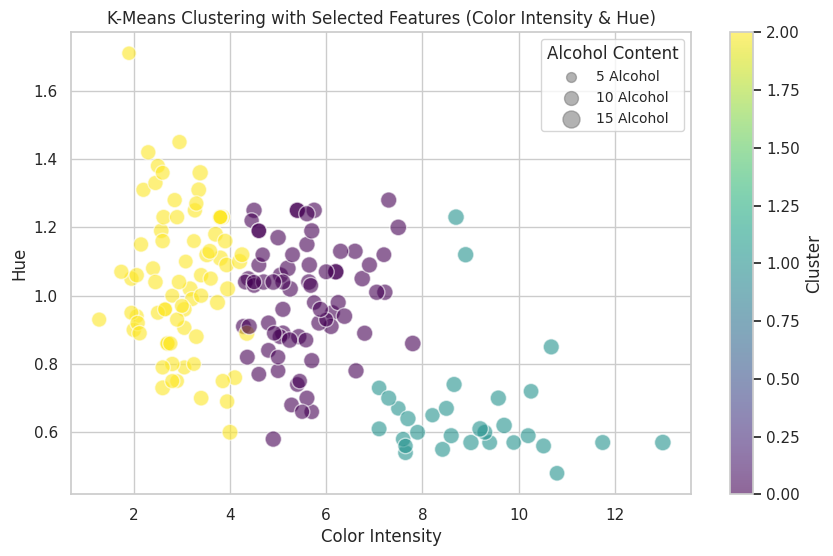

K-Means Inertia with Selected Features: 273.4034466201562


In [ ]:
# Define selected features for clustering
selected_features = ['Total_Phenols', 'Nonflavanoid_Phenols', 'Color_Intensity', 'Hue', 'OD280']

# Apply K-Means clustering on selected features
X_selected = df[selected_features]
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_selected)

# Visualize clusters using two of the selected features, say 'Color_Intensity' and 'Hue'
plt.figure(figsize=(10, 6))

# Use bubble size to represent alcohol content
scatter = plt.scatter(df['Color_Intensity'], df['Hue'],
                      c=df['Cluster'], cmap='viridis',
                      s=df['Alcohol']*10, alpha=0.6, edgecolor='w')

# Add labels and title
plt.xlabel('Color Intensity')
plt.ylabel('Hue')
plt.title('K-Means Clustering with Selected Features (Color Intensity & Hue)')

# Create a color bar for cluster colors
cbar = plt.colorbar(scatter)
cbar.set_label('Cluster')

# Add a legend for alcohol content (bubble size)
for alcohol_level in [5, 10, 15]:
    plt.scatter([], [], s=alcohol_level*10, color='gray', alpha=0.6, label=str(alcohol_level) + ' Alcohol')

plt.legend(title='Alcohol Content', loc='upper right', fontsize='small')

plt.show()

# Inertia to evaluate clustering
print("K-Means Inertia with Selected Features:", kmeans.inertia_)


## Cluster Interpretation

### Yellow Cluster (left):
- Wines in this cluster have relatively low Color Intensity and moderate Hue values.
- The bubble sizes suggest a moderate to low Alcohol Content, indicating that these wines might be lighter in terms of alcohol percentage, correlating with their lighter color intensity.

### Purple Cluster (center):
- These wines exhibit moderate Color Intensity and a wide range of Hue values, from low to moderately high.
- Alcohol content, as indicated by bubble size, appears to be slightly higher on average compared to the yellow cluster, but still varies within the cluster. The wines in this cluster may represent a mix of medium-bodied wines.

### Green Cluster (right):
- This cluster stands out with the highest Color Intensity values and relatively low Hue.
- The bubble sizes in this cluster suggest a wide range of Alcohol Content, including some of the wines with the highest alcohol levels in the dataset. This could indicate that high Color Intensity is associated with stronger wines, potentially offering a more robust or intense flavor.

## Conclusion:
- **Separation:** The clusters are well-separated based on the chemical properties (Color Intensity and Hue), indicating distinct groups of wines. However, alcohol content shows variation within each cluster.
- **Alcohol Content Correlation:** The cluster with higher Color Intensity (green) tends to contain wines with higher alcohol content, while the yellow cluster with lower Color Intensity is associated with lighter alcohol levels.
- **Chemical Composition Impact:** This suggests that certain chemical properties (e.g., Color Intensity) may play a significant role in determining alcohol content, even if it's not the sole defining feature for clustering.

Further analysis could involve comparing additional features and their relationships to alcohol content or using more advanced clustering validation techniques.


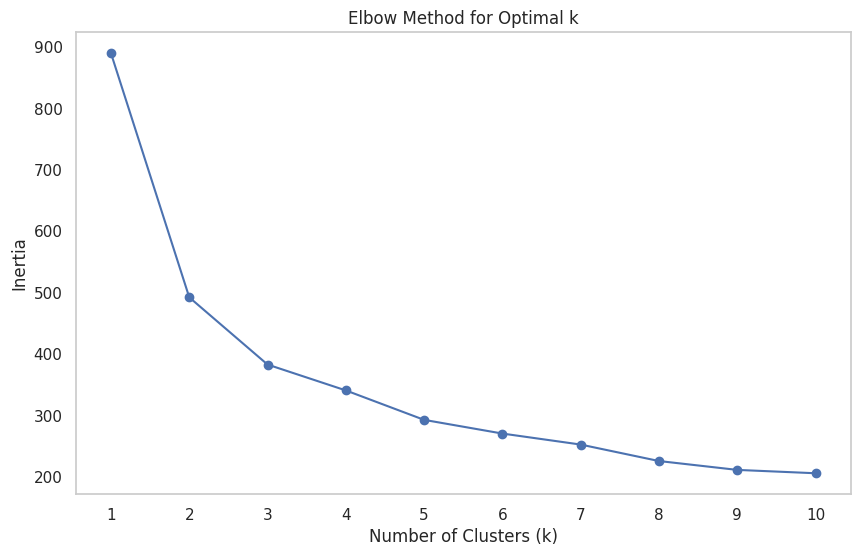

In [ ]:
# Elbow method to find the optimal number of clusters
inertia_values = []
cluster_range = range(1, 11)

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(cluster_range, inertia_values, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(cluster_range)
plt.grid()
plt.show()


### K-Means Clustering Evaluation (k=3)

#### Inertia:
- **Inertia**: 382.9049
- While a **lower inertia** suggests tighter and more cohesive clusters, this value alone doesn't confirm the best number of clusters. Inertia tends to decrease as the number of clusters increases, so this result needs to be evaluated alongside other metrics. Given the moderate value, it indicates the clusters are reasonably compact but not perfect.

#### Elbow Method:
- The **elbow point** occurs at **k=3**, indicating that increasing the number of clusters beyond this point provides diminishing returns in reducing inertia. This suggests that 3 clusters offer a good balance between simplicity and performance.

#### Cluster Visualization:
- PCA reveals mostly **separated clusters**, with very few overlap exists, suggesting meaningful grouping.


### Conclusion:
- The **inertia** of 382.9049 and the **elbow point at k=3** suggest that three clusters provide a reasonable solution for this dataset.

**Classification Technique**

In [ ]:
# Ensure 'Quality' column is categorical
df['Quality'] = pd.cut(df['Alcohol'], bins=[0, 10, 12, float('inf')], labels=['Low', 'Medium', 'High'])

# Prepare features and target
X_knn = df.drop(['Quality', 'Alcohol'], axis=1)  # Features
y_knn = df['Quality']  # Target variable

# Split the data
X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(X_knn, y_knn, test_size=0.2, random_state=42)

# Create KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_knn, y_train_knn)

# Make predictions
y_pred_knn = knn.predict(X_test_knn)

# Evaluation
print(confusion_matrix(y_test_knn, y_pred_knn))
print(classification_report(y_test_knn, y_pred_knn))

[[33  0]
 [ 3  0]]
              precision    recall  f1-score   support

        High       0.92      1.00      0.96        33
      Medium       0.00      0.00      0.00         3

    accuracy                           0.92        36
   macro avg       0.46      0.50      0.48        36
weighted avg       0.84      0.92      0.88        36



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**KNN Model Evaluation**
##Confusion Matrix:
[[33 0] [ 3 0]]
- 33 "High" quality wines correctly classified.
- 3 "Medium" quality wines misclassified as "High."

#### Classification Report:
| Metric     | High  | Medium |
|------------|-------|--------|
| Precision  | 0.92  | 0.00   |
| Recall     | 1.00  | 0.00   |
| F1-score   | 0.96  | 0.00   |

- **High precision and recall** for "High" wines (0.92 and 1.00), but **0 precision and recall** for "Medium" wines.
- **Accuracy**: 92%

#### Key Issues:
- **Class imbalance**: The model predicts "High" wines well but completely misses "Medium" wines due to data imbalance.
- **Bias**: The model is biased towards the majority class ("High").

#### Next Steps:
- **Balance the dataset** (e.g., oversampling "Medium" wines or undersampling "High").
- **Tune k** or try different models (e.g., decision trees or random forests).

This evaluation shows that despite high accuracy, the model struggles with minority class predictions, necessitating class balancing and model improvements.


**Using Naive Bayes Classifier**

In [ ]:
# Import the necessary module
from sklearn.naive_bayes import GaussianNB

# Create Naive Bayes model
nb = GaussianNB()
nb.fit(X_train_knn, y_train_knn)

# Make predictions
y_pred_nb = nb.predict(X_test_knn)

# Evaluation
print(confusion_matrix(y_test_knn, y_pred_nb))
print(classification_report(y_test_knn, y_pred_nb))


[[27  6]
 [ 0  3]]
              precision    recall  f1-score   support

        High       1.00      0.82      0.90        33
      Medium       0.33      1.00      0.50         3

    accuracy                           0.83        36
   macro avg       0.67      0.91      0.70        36
weighted avg       0.94      0.83      0.87        36



### Naive Bayes Results Evaluation:

#### Confusion Matrix:
[[27 6] [ 0 3]]
- **27 "High" wines** correctly classified.
- **6 "High" wines** misclassified as "Medium."
- **3 "Medium" wines** correctly classified.

#### Classification Report:

| Metric     | High  | Medium |
|------------|-------|--------|
| Precision  | 1.00  | 0.33   |
| Recall     | 0.82  | 1.00   |
| F1-score   | 0.90  | 0.50   |

- **Accuracy**: 83%
- **Macro Avg F1**: 0.70
- **Weighted Avg F1**: 0.87

### Key Insights:
- **Naive Bayes** improves recall for the "Medium" class (1.00) but misclassifies 6 "High" wines as "Medium."
- **Precision for "Medium" wines** is low (0.33) due to these misclassifications.
- Overall, Naive Bayes performs better than KNN for handling the minority class.


**Neural Networks For Regression**

In [ ]:
from keras.models import Sequential
from keras.layers import Dense

# Step 1: Building the Neural Network Model
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))  # Input layer
model.add(Dense(32, activation='relu'))  # Hidden layer
model.add(Dense(1))  # Output layer (predicting a single value)

# Step 2: Compile the Model
model.compile(optimizer='adam', loss='mean_squared_error')

# Step 3: Fit the Model to the Training Data
model.fit(X_train, y_train, epochs=100, batch_size=10, verbose=0)

# Step 4: Predict on the Test Set
y_pred_nn = model.predict(X_test)

# Step 5: Evaluate the Neural Network Model
mse_nn = mean_squared_error(y_test, y_pred_nn)
r2_nn = r2_score(y_test, y_pred_nn)

print(f"Neural Network MSE: {mse_nn}, R-squared: {r2_nn}")


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Neural Network MSE: 0.7927643587144808, R-squared: -0.3278338676439143


### Neural Network Results Evaluation:

#### Metrics:
- **Mean Squared Error (MSE)**: 0.7928
- **R-squared (R²)**: -0.3278

### Key Insights:
- **High MSE**: The neural network’s MSE (0.7928) indicates that the model is not performing well in terms of minimizing the error between predicted and actual values. In comparison to previous models like Naive Bayes and KNN, this value is significantly higher.

- **Negative R-squared**: The R-squared value of -0.3278 suggests that the model is performing worse than a simple horizontal line predicting the mean of the target variable. In other words, the neural network is **failing to explain any variance** in the data, and its predictions are not meaningful.

### Conclusion:
- The neural network is underperforming in this case, both in terms of **MSE** and **R-squared**. This suggests that the current configuration of the neural network (MLP) is not suitable for this dataset, or the model requires significant tuning.
